In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [36]:
import pandas as pd
data=pd.read_csv("Sales dataset 3.csv")
print(data)

    Month  Sales
0       1   1200
1       2   1350
2       3   1400
3       4   1500
4       5   1700
5       6   1800
6       7   2000
7       8   2100
8       9   2250
9      10   2400
10     11   2550
11     12   2700
12     13   2850
13     14   2950
14     15   3100
15     16   3250
16     17   3400
17     18   3550
18     19   3700
19     20   3850
20     21   4000
21     22   4200
22     23   4350
23     24   4500


In [37]:
print("===== DATASET =====")
print(data.head())

===== DATASET =====
   Month  Sales
0      1   1200
1      2   1350
2      3   1400
3      4   1500
4      5   1700


In [38]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
Month    0
Sales    0
dtype: int64


In [39]:
data = data.drop_duplicates()

In [40]:
X = data[["Month"]]
y = data[["Sales"]]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [42]:
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel Trained Successfully!")


Model Trained Successfully!


In [43]:
y_pred = model.predict(X_test)

In [44]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


In [45]:
print("\n===== MODEL EVALUATION =====")
print("Mean Absolute Error :", round(mae,2))
print("Root Mean Squared Error :", round(rmse,2))
print("R2 Score :", round(r2,4))


===== MODEL EVALUATION =====
Mean Absolute Error : 34.32
Root Mean Squared Error : 47.78
R2 Score : 0.9971


In [49]:
future_months = pd.DataFrame({
    "Month":[25,26,27,28,29,30]
})
future_sales = model.predict(future_months)

print("\n===== FUTURE SALES PREDICTION =====")

for month,sales in zip(future_months["Month"],future_sales):
    print(f"Month {month} --> {sales[0]:.2f}")



===== FUTURE SALES PREDICTION =====
Month 25 --> 4595.96
Month 26 --> 4741.55
Month 27 --> 4887.14
Month 28 --> 5032.74
Month 29 --> 5178.33
Month 30 --> 5323.92


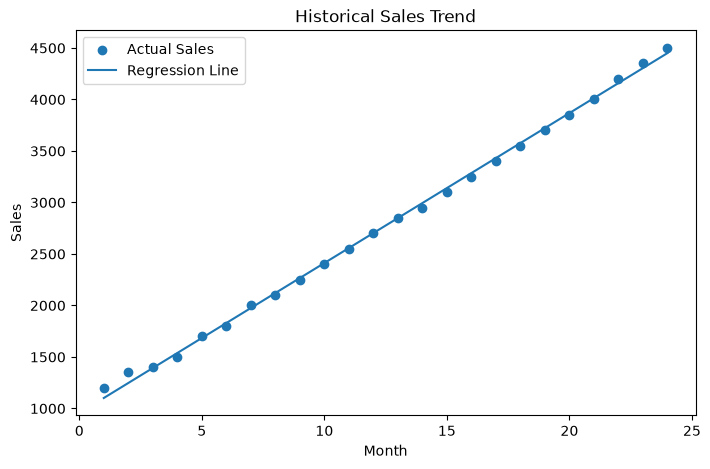

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(X,y,label="Actual Sales")

plt.plot(X,model.predict(X),label="Regression Line")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Historical Sales Trend")
plt.legend()

plt.show()

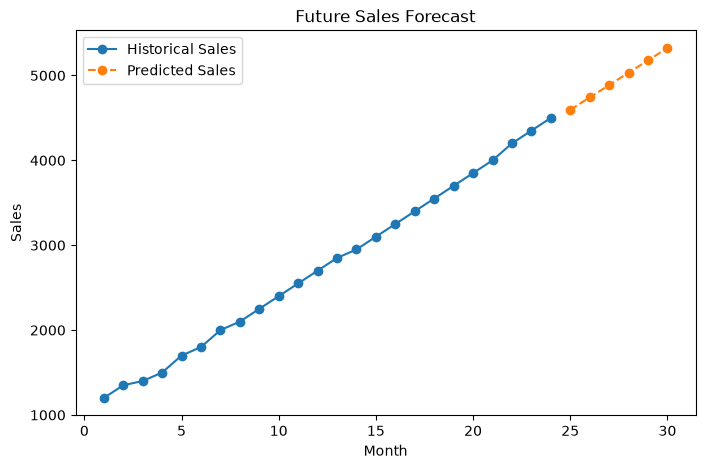

In [51]:
plt.figure(figsize=(8,5))

plt.plot(data["Month"],data["Sales"],marker='o',label="Historical Sales")

plt.plot(
    future_months["Month"],
    future_sales,
    marker='o',
    linestyle='--',
    label="Predicted Sales"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Future Sales Forecast")
plt.legend()

plt.show()